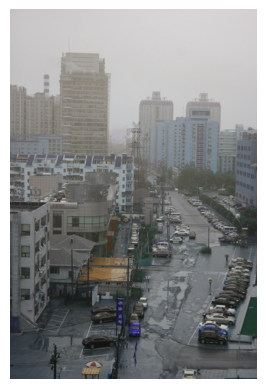

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


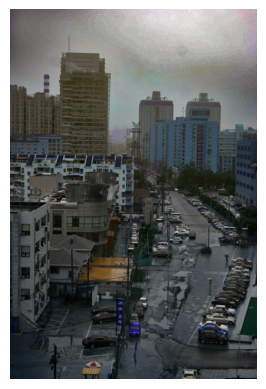

In [5]:
import cv2;
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math;
import numpy as np;
import os

# 定义一个函数，用于计算图像的暗通道
def DarkChannel(im, sz):
    # 分别获取图像的B, G, R通道
    b, g, r = cv2.split(im)
    # 计算暗通道，即在三个通道中取最小值
    dc = cv2.min(cv2.min(r, g), b)
    # 使用结构元素对暗通道进行腐蚀操作，以去除小的亮斑
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (sz, sz))
    dark = cv2.erode(dc, kernel)
    return dark

# 定义一个函数，用于估计大气光, 大气光是一个图像去雾过程中的参数，是一种假设，即在图像中的某些区域，由于大气的原因，图像的亮度会比较高
def AtmLight(im, dark):
    # 获取图像的高度和宽度
    [h, w] = im.shape[:2]
    imsz = h * w
    # 计算需要采样的像素数量
    numpx = int(max(math.floor(imsz / 1000), 1))
    # 将暗通道和图像数据重塑为一维数组
    darkvec = dark.reshape(imsz)
    imvec = im.reshape(imsz, 3)
    # 获取暗通道中最暗的像素索引
    indices = darkvec.argsort()
    indices = indices[imsz - numpx::]
    # 计算大气光的估计值
    atmsum = np.zeros([1, 3])
    for ind in range(1, numpx):
        atmsum = atmsum + imvec[indices[ind]]
    A = atmsum / numpx
    return A

# 定义一个函数，用于估计透射图
def TransmissionEstimate(im, A, sz):
    # 设置omega值，用于调整暗通道的权重
    omega = 0.95
    # 创建一个空数组用于存储调整后的图像
    im3 = np.empty(im.shape, im.dtype)
    # 将图像的每个通道除以对应的大气光，以标准化
    for ind in range(0, 3):
        im3[:, :, ind] = im[:, :, ind] / A[0, ind]
    # 计算透射图
    transmission = 1 - omega * DarkChannel(im3, sz)
    return transmission

# 定义一个函数，用于引导滤波器
def Guidedfilter(im, p, r, eps):
    # 使用boxFilter进行均值滤波
    mean_I = cv2.boxFilter(im, cv2.CV_64F, (r, r))
    mean_p = cv2.boxFilter(p, cv2.CV_64F, (r, r))
    mean_Ip = cv2.boxFilter(im * p, cv2.CV_64F, (r, r))
    cov_Ip = mean_Ip - mean_I * mean_p
    mean_II = cv2.boxFilter(im * im, cv2.CV_64F, (r, r))
    var_I = mean_II - mean_I * mean_I
    # 计算引导滤波器的参数a和b
    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I
    mean_a = cv2.boxFilter(a, cv2.CV_64F, (r, r))
    mean_b = cv2.boxFilter(b, cv2.CV_64F, (r, r))
    # 应用引导滤波器
    q = mean_a * im + mean_b
    return q


# 定义一个函数，用于细化透射图
def TransmissionRefine(im, et):
    # 将图像转换为灰度图并归一化
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    gray = np.float64(gray) / 255
    # 设置引导滤波器的参数
    r = 60
    eps = 0.0001
    # 使用引导滤波器细化透射图
    t = Guidedfilter(gray, et, r, eps)
    return t

# 定义一个函数，用于恢复图像
def Recover(im, t, A, tx = 0.1):
    # 创建一个空数组用于存储恢复后的图像
    res = np.empty(im.shape, im.dtype)
    # 确保透射图的值不小于tx
    t = cv2.max(t, tx)
    # 恢复图像的每个通道
    for ind in range(0, 3):
        res[:, :, ind] = (im[:, :, ind] - A[0, ind]) / t + A[0, ind]
    return res

if __name__ == '__main__':
    import sys
    try:
        fn = sys.argv[1]
    except:
        fn = './image/15.png'

    def nothing(*argv):
        pass

    fn = './image/15.png'
    src = cv2.imread(fn);
    I = src.astype('float64')/255;
 
    dark = DarkChannel(I,15);
    A = AtmLight(I,dark);
    te = TransmissionEstimate(I,A,15);
    t = TransmissionRefine(src,te);
    J = Recover(I,t,A,0.1);

    cv2.imshow("dark",dark);
    cv2.imshow("t",t);
    cv2.imshow('I',src);
    cv2.imshow('J',J);
    # cv2.imwrite("./image/J.png",J*255);
    cv2.waitKey();
    plt.imshow(src)
    plt.axis('off')
    plt.show()
    plt.imshow(J)
    plt.axis('off')
    plt.show()

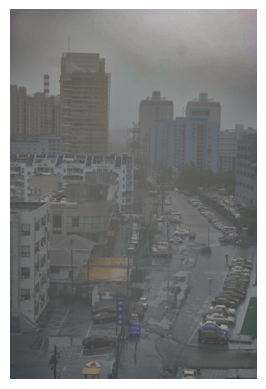

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


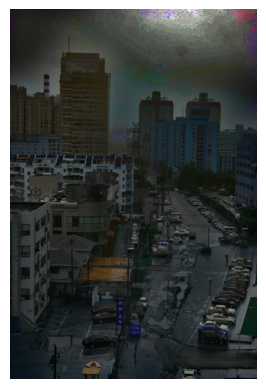

In [6]:
fn = './image/1.png'
src = cv2.imread(fn);
I = src.astype('float64')/255;

dark = DarkChannel(I,15);
A = AtmLight(I,dark);
te = TransmissionEstimate(I,A,15);
t = TransmissionRefine(src,te);
J = Recover(I,t,A,0.1);

plt.imshow(src)
plt.axis('off')
plt.show()
plt.imshow(J)
plt.axis('off')
plt.show()

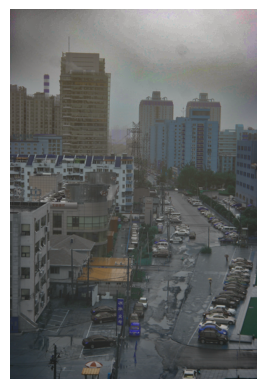

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


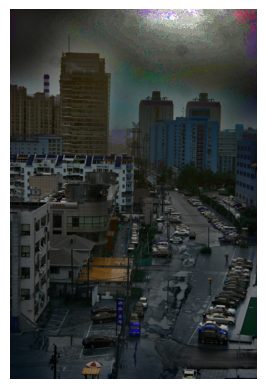

In [7]:
fn = './image/2.png'
src = cv2.imread(fn);
I = src.astype('float64')/255;

dark = DarkChannel(I,15);
A = AtmLight(I,dark);
te = TransmissionEstimate(I,A,15);
t = TransmissionRefine(src,te);
J = Recover(I,t,A,0.1);

plt.imshow(src)
plt.axis('off')
plt.show()
plt.imshow(J)
plt.axis('off')
plt.show()

第一张照片是作者给出的，后面两张是我使用加雾算法加的，可以看出手工加雾后去雾会得到较暗的照片， 推测是加的雾气削弱了原图的光照